In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

# EMA 쓴 결과값 확인 코드

[Client A] raw → shape: (3300, 16), class balance: {0: 2831, 1: 469}
[Client B] raw → shape: (530, 16), class balance: {0: 474, 1: 56}
[Client C] raw → shape: (3245, 16), class balance: {0: 2915, 1: 330}
[Client D] raw → shape: (460, 16), class balance: {0: 406, 1: 54}
[Client A] train after SMOTE → shape: (3958, 16), class balance: {0: 1979, 1: 1979}
[Client A] val   (no SMOTE)   → shape: (330, 16), class balance: {0: 279, 1: 51}
[Client A] test  (no SMOTE)   → shape: (660, 16), class balance: {0: 573, 1: 87}
[Client B] train after SMOTE → shape: (664, 16), class balance: {0: 332, 1: 332}
[Client B] val   (no SMOTE)   → shape: (53, 16), class balance: {0: 48, 1: 5}
[Client B] test  (no SMOTE)   → shape: (106, 16), class balance: {0: 94, 1: 12}
[Client C] train after SMOTE → shape: (4100, 16), class balance: {1: 2050, 0: 2050}
[Client C] val   (no SMOTE)   → shape: (324, 16), class balance: {0: 285, 1: 39}
[Client C] test  (no SMOTE)   → shape: (650, 16), class balance: {0: 580, 1: 70}

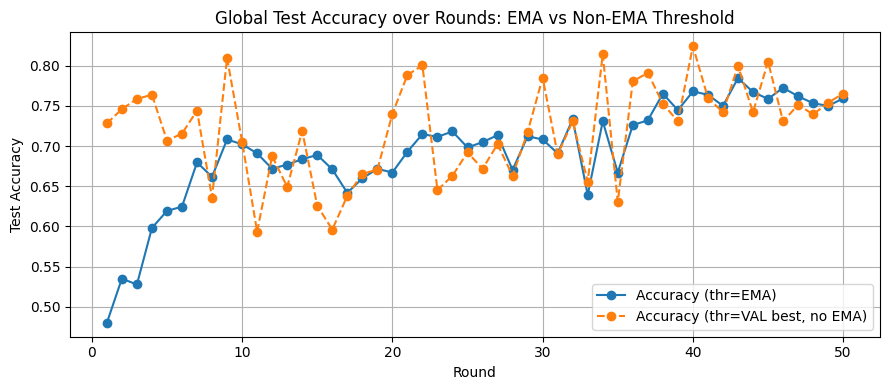

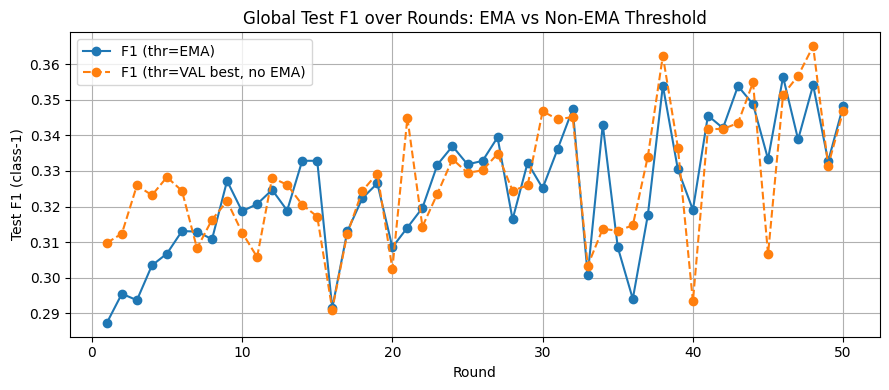

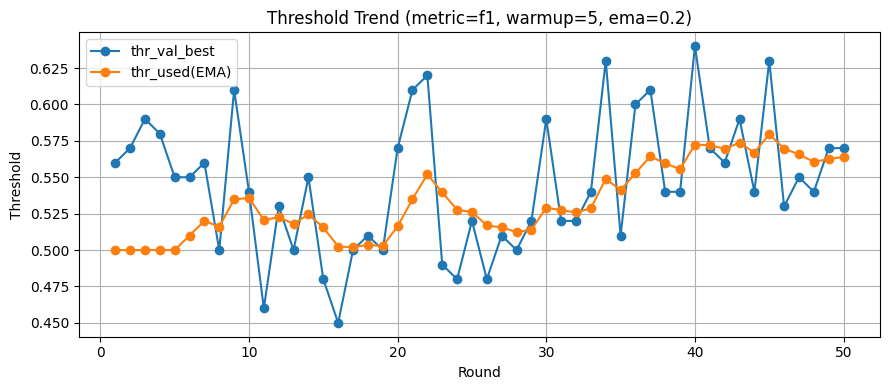


 Final Global Evaluation (EMA final thr)
Final thr_used(EMA)=0.56 | Acc=0.7593 | F1=0.3483 | ROC-AUC=0.7597 | pos_rate=0.252
CM: TN=1048, FP=283, FN=80, TP=97
              precision    recall  f1-score   support

           0     0.9291    0.7874    0.8524      1331
           1     0.2553    0.5480    0.3483       177

    accuracy                         0.7593      1508
   macro avg     0.5922    0.6677    0.6003      1508
weighted avg     0.8500    0.7593    0.7932      1508


 Per-Client Fine-tuning Report (thr=EMA final)

--- Client A Fine-tuning ---
[Client A] thr=0.56 | Acc=0.7561 | F1=0.3482 | ROC-AUC=0.7373 | pos_rate=0.242
CM: TN=456, FP=117, FN=44, TP=43
              precision    recall  f1-score   support

           0     0.9120    0.7958    0.8500       573
           1     0.2687    0.4943    0.3482        87

    accuracy                         0.7561       660
   macro avg     0.5904    0.6450    0.5991       660
weighted avg     0.8272    0.7561    0.7838       6

In [ ]:
# ============================================================
# Federated Learning (DeepMLP)
# + αᵢ Mitigation (n_i, c_i, t_i) softmax aggregation
# + Train-only SMOTE (per-client)
# + FocalLoss + FedProx + FedBN-style aggregation
# + Threshold tuning on VAL
# + Compare: EMA threshold vs Non-EMA threshold (thr_val_best)
# + Round logging: Global(Test) Acc/F1/CM for BOTH settings
# + Final: Global report + Per-client fine-tuning report (uses EMA final_thr)
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score, classification_report, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1'
]

# αᵢ hyperparams
RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) Data load + split + (SMOTE only on TRAIN)
# =========================================================
def load_excel_binary_raw(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    return X, y


def oversample_train_only(X_train, y_train, sampling_strategy=1.0, k_neighbors=5):
    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors, sampling_strategy=sampling_strategy)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res


def build_clients(path_map, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
                  smote_sampling_strategy=1.0, smote_k=5):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-9

    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary_raw(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] raw → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    cols = list(cols)

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat_all = v["X"][cols].copy()
        y_all = v["y"].astype(int)

        n = len(feat_all)
        idx = np.arange(n)
        rng = np.random.RandomState(SEED)
        rng.shuffle(idx)

        n_train = int(train_ratio * n)
        n_val   = int(val_ratio * n)

        tr_idx = idx[:n_train]
        va_idx = idx[n_train:n_train+n_val]
        te_idx = idx[n_train+n_val:]

        X_train_raw = feat_all.iloc[tr_idx].copy()
        y_train_raw = y_all[tr_idx]

        X_val_raw   = feat_all.iloc[va_idx].copy()
        y_val_raw   = y_all[va_idx]

        X_test_raw  = feat_all.iloc[te_idx].copy()
        y_test_raw  = y_all[te_idx]

        mu = X_train_raw.mean()
        sigma = X_train_raw.std().replace(0, 1)

        X_train_std = (X_train_raw - mu) / sigma
        X_val_std   = (X_val_raw   - mu) / sigma
        X_test_std  = (X_test_raw  - mu) / sigma

        X_train_sm, y_train_sm = oversample_train_only(
            X_train_std, y_train_raw,
            sampling_strategy=smote_sampling_strategy,
            k_neighbors=smote_k
        )

        print(f"[Client {cid}] train after SMOTE → shape: {X_train_sm.shape}, class balance: {pd.Series(y_train_sm).value_counts().to_dict()}")
        print(f"[Client {cid}] val   (no SMOTE)   → shape: {X_val_std.shape}, class balance: {pd.Series(y_val_raw).value_counts().to_dict()}")
        print(f"[Client {cid}] test  (no SMOTE)   → shape: {X_test_std.shape}, class balance: {pd.Series(y_test_raw).value_counts().to_dict()}")

        Xtr = torch.tensor(np.asarray(X_train_sm).astype(np.float32))
        ytr = torch.tensor(y_train_sm, dtype=torch.long)

        Xva = torch.tensor(np.asarray(X_val_std).astype(np.float32))
        yva = torch.tensor(y_val_raw, dtype=torch.long)

        Xte = torch.tensor(np.asarray(X_test_std).astype(np.float32))
        yte = torch.tensor(y_test_raw, dtype=torch.long)

        clients[cid] = {
            "train": TensorDataset(Xtr, ytr),
            "val":   TensorDataset(Xva, yva),
            "test":  TensorDataset(Xte, yte),
        }

        metas[cid] = {
            "n_samples_raw": int(len(y_all)),
            "train_class_counts_raw": pd.Series(y_train_raw).value_counts().to_dict(),
            "val_class_counts_raw":   pd.Series(y_val_raw).value_counts().to_dict(),
            "test_class_counts_raw":  pd.Series(y_test_raw).value_counts().to_dict(),
        }

    return clients, metas, cols


# =========================================================
# 2) Model
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ components + aggregation
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components, rho, beta, theta, use_fedbn=True, alpha_temp=1.0):
    """
    αᵢ = softmax( (log(nᵢ^ρ)+log(cᵢ^β)+log(tᵢ^θ)) * alpha_temp )
    """
    logits = {}
    for cid, comp in alpha_components.items():
        s = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )
        logits[cid] = s * float(alpha_temp)

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            global_sd[k] = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items()).clone()

    return global_sd, alphas


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox = prox + torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) Predict + threshold search + evaluate
# =========================================================
def predict_probs(model, dataset, device):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probs_all, y_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.append(probs)
            y_all.append(y.numpy())

    return np.concatenate(probs_all), np.concatenate(y_all)


def find_best_threshold_from_probs(probs, y_true, metric="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

    best_t, best_score = 0.5, -1e18
    best_aux = -1e18

    for t in grid:
        y_pred = (probs >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score, best_t = score, t

        elif metric == "recall":
            rec = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if rec > best_score or (rec == best_score and prec > best_aux):
                best_score, best_aux, best_t = rec, prec, t

        elif metric == "youden":
            cm = confusion_matrix(y_true, y_pred)
            if cm.size != 4:
                continue
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn + 1e-12)
            fpr = fp / (fp + tn + 1e-12)
            score = tpr - fpr
            if score > best_score:
                best_score, best_t = score, t
        else:
            raise ValueError("metric must be one of: f1, recall, youden")

    return float(best_t), float(best_score)


def evaluate_with_threshold(model, dataset, device, threshold):
    probs, y_true = predict_probs(model, dataset, device)
    y_pred = (probs >= threshold).astype(int)

    acc = float(np.mean(y_true == y_pred))
    f1  = float(f1_score(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    pos_rate = float(np.mean(y_pred))
    try:
        auc = float(roc_auc_score(y_true, probs))
    except Exception:
        auc = float("nan")

    return acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate


# =========================================================
# 7) Fine-tuning
# =========================================================
def finetune_local(model, train_ds, device, lr=8e-4, epochs=5):
    ft_model = copy.deepcopy(model).to(device)
    ft_model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(ft_model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = ft_model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

    return ft_model


# =========================================================
# 8) Main
# =========================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)

    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--lr", type=float, default=8e-4)
    parser.add_argument("--local_epochs", type=int, default=5)

    parser.add_argument("--smote_ratio", type=float, default=1.0)
    parser.add_argument("--smote_k", type=int, default=5)

    parser.add_argument("--alpha_temp", type=float, default=1.0)

    parser.add_argument("--th_metric", type=str, default="f1")        # f1 / recall / youden
    parser.add_argument("--thr_warmup", type=int, default=5)
    parser.add_argument("--thr_init", type=float, default=0.50)
    parser.add_argument("--thr_ema", type=float, default=0.20)
    parser.add_argument("--thr_grid_min", type=float, default=0.05)
    parser.add_argument("--thr_grid_max", type=float, default=0.95)
    parser.add_argument("--thr_grid_step", type=float, default=0.01)

    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(
        paths,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
        smote_sampling_strategy=args.smote_ratio,
        smote_k=args.smote_k
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["train"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim).to(device)

    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    combined_val  = torch.utils.data.ConcatDataset([v["val"]  for v in clients.values()])
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    thr_grid = np.round(
        np.arange(args.thr_grid_min, args.thr_grid_max + 1e-12, args.thr_grid_step), 2
    )

    # -----------------------
    # Histories (EMA vs Non-EMA)
    # -----------------------
    rounds_axis = list(range(1, args.rounds + 1))

    thr_val_history      = []
    thr_used_history     = []

    # EMA applied
    acc_ema_history      = []
    f1_ema_history       = []
    posrate_ema_history  = []

    # Non-EMA (direct val-best threshold each round)
    acc_noema_history    = []
    f1_noema_history     = []
    posrate_noema_history= []

    alpha_history        = []

    # EMA threshold state
    thr_used = float(args.thr_init)

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        print(" Participating:", selected)

        state_dicts = {}
        alpha_components = {}
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # local train
        for cid in selected:
            ds_train = clients[cid]["train"]
            class_counts_raw = metas[cid]["train_class_counts_raw"]

            sd = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=args.lr,
                epochs=args.local_epochs,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            n_i = math.sqrt(metas[cid]["n_samples_raw"])
            c_i = compute_ci(class_counts_raw)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        new_global_sd, alphas = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO, beta=BETA, theta=THETA,
            use_fedbn=True,
            alpha_temp=args.alpha_temp
        )
        global_model.load_state_dict(new_global_sd)
        alpha_history.append((rnd, alphas))

        # ----- threshold tuning on VAL -----
        val_probs, val_true = predict_probs(global_model, combined_val, device)
        thr_val_best, thr_val_score = find_best_threshold_from_probs(
            val_probs, val_true, metric=args.th_metric, grid=thr_grid
        )
        thr_val_history.append(thr_val_best)

        # ----- EMA threshold update (after warmup) -----
        if rnd <= args.thr_warmup:
            thr_used = float(args.thr_init)
        else:
            lam = float(args.thr_ema)
            thr_used = (1.0 - lam) * thr_used + lam * thr_val_best

        thr_used_history.append(float(thr_used))

        # ==========================
        # Evaluate on TEST (EMA)
        # ==========================
        acc_e, f1_e, auc_e, (tn_e, fp_e, fn_e, tp_e), _, _, pos_e = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_used)
        )
        acc_ema_history.append(acc_e)
        f1_ema_history.append(f1_e)
        posrate_ema_history.append(pos_e)

        # ==========================
        # Evaluate on TEST (Non-EMA)
        # ==========================
        acc_n, f1_n, auc_n, (tn_n, fp_n, fn_n, tp_n), _, _, pos_n = evaluate_with_threshold(
            global_model, combined_test, device, threshold=float(thr_val_best)
        )
        acc_noema_history.append(acc_n)
        f1_noema_history.append(f1_n)
        posrate_noema_history.append(pos_n)

        print(f"[Round {rnd}] alpha_temp={args.alpha_temp:.2f}, mu={args.mu:.4f}")
        print(f"[Round {rnd}] VAL tuned thr({args.th_metric})={thr_val_best:.2f} (score={thr_val_score:.4f}) | EMA thr_used={thr_used:.2f}")
        print(f"[Round {rnd}] TEST (EMA)    Acc={acc_e:.4f}, F1={f1_e:.4f}, AUC={auc_e:.4f}, TN={tn_e}, FP={fp_e}, FN={fn_e}, TP={tp_e}, pos_rate={pos_e:.3f}")
        print(f"[Round {rnd}] TEST (NoEMA)  Acc={acc_n:.4f}, F1={f1_n:.4f}, AUC={auc_n:.4f}, TN={tn_n}, FP={fp_n}, FN={fn_n}, TP={tp_n}, pos_rate={pos_n:.3f}")

    # =========================
    # Plots: Accuracy (EMA vs Non-EMA)
    # =========================
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, acc_ema_history, marker='o', label="Accuracy (thr=EMA)")
    plt.plot(rounds_axis, acc_noema_history, linestyle='--', marker='o', label="Accuracy (thr=VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test Accuracy")
    plt.title("Global Test Accuracy over Rounds: EMA vs Non-EMA Threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (선택) F1도 같이 비교하고 싶으면 유지
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, f1_ema_history, marker='o', label="F1 (thr=EMA)")
    plt.plot(rounds_axis, f1_noema_history, linestyle='--', marker='o', label="F1 (thr=VAL best, no EMA)")
    plt.xlabel("Round")
    plt.ylabel("Test F1 (class-1)")
    plt.title("Global Test F1 over Rounds: EMA vs Non-EMA Threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Threshold trend
    plt.figure(figsize=(9,4))
    plt.plot(rounds_axis, thr_val_history, marker='o', label="thr_val_best")
    plt.plot(rounds_axis, thr_used_history, marker='o', label="thr_used(EMA)")
    plt.xlabel("Round")
    plt.ylabel("Threshold")
    plt.title(f"Threshold Trend (metric={args.th_metric}, warmup={args.thr_warmup}, ema={args.thr_ema})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================
    # Final Global Report (EMA final threshold)
    # =========================
    final_thr = float(thr_used_history[-1]) if len(thr_used_history) else float(args.thr_init)
    acc, f1, auc, (tn, fp, fn, tp), y_true, y_pred, pos_rate = evaluate_with_threshold(
        global_model, combined_test, device, threshold=final_thr
    )
    print("\n==============================")
    print(" Final Global Evaluation (EMA final thr)")
    print("==============================")
    print(f"Final thr_used(EMA)={final_thr:.2f} | Acc={acc:.4f} | F1={f1:.4f} | ROC-AUC={auc:.4f} | pos_rate={pos_rate:.3f}")
    print(f"CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    # =========================
    # Per-client Fine-tuning (thr fixed to EMA final_thr)
    # =========================
    print("\n==============================")
    print(" Per-Client Fine-tuning Report (thr=EMA final)")
    print("==============================")

    for cid in clients.keys():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_model = finetune_local(
            model=global_model,
            train_ds=clients[cid]["train"],
            device=device,
            lr=args.lr,
            epochs=args.ft_epochs
        )

        acc_c, f1_c, auc_c, (tn_c, fp_c, fn_c, tp_c), ytc, ypc, pos_rate_c = evaluate_with_threshold(
            ft_model, clients[cid]["test"], device, threshold=final_thr
        )
        print(f"[Client {cid}] thr={final_thr:.2f} | Acc={acc_c:.4f} | F1={f1_c:.4f} | ROC-AUC={auc_c:.4f} | pos_rate={pos_rate_c:.3f}")
        print(f"CM: TN={tn_c}, FP={fp_c}, FN={fn_c}, TP={tp_c}")
        print(classification_report(ytc, ypc, digits=4, zero_division=0))
